<a href="https://colab.research.google.com/github/Kenny625819/Applied-Data-Science/blob/main/%E9%AA%A8%E7%B2%97%E9%AC%86%E7%97%87%E3%83%A1%E3%82%BF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Strict main analysis
{'k': 6, 'events_total': 536, 'n_total': 607, 'crude_rate': 0.8830313014827018, 'pooled_rate': 0.862842415628366, 'ci_low': 0.7378888000524282, 'ci_high': 0.933589324148851, 'tau2': 0.6676576538303757, 'Q': 32.0186829956202, 'df': 5, 'I2': 84.38411723341667}

Expanded sensitivity analysis
{'k': 14, 'events_total': 651, 'n_total': 747, 'crude_rate': 0.8714859437751004, 'pooled_rate': 0.8301993246524533, 'ci_low': 0.7531567376247645, 'ci_high': 0.886809841731624, 'tau2': 0.4331309416117844, 'Q': 42.12400027929245, 'df': 13, 'I2': 69.13873346831542}


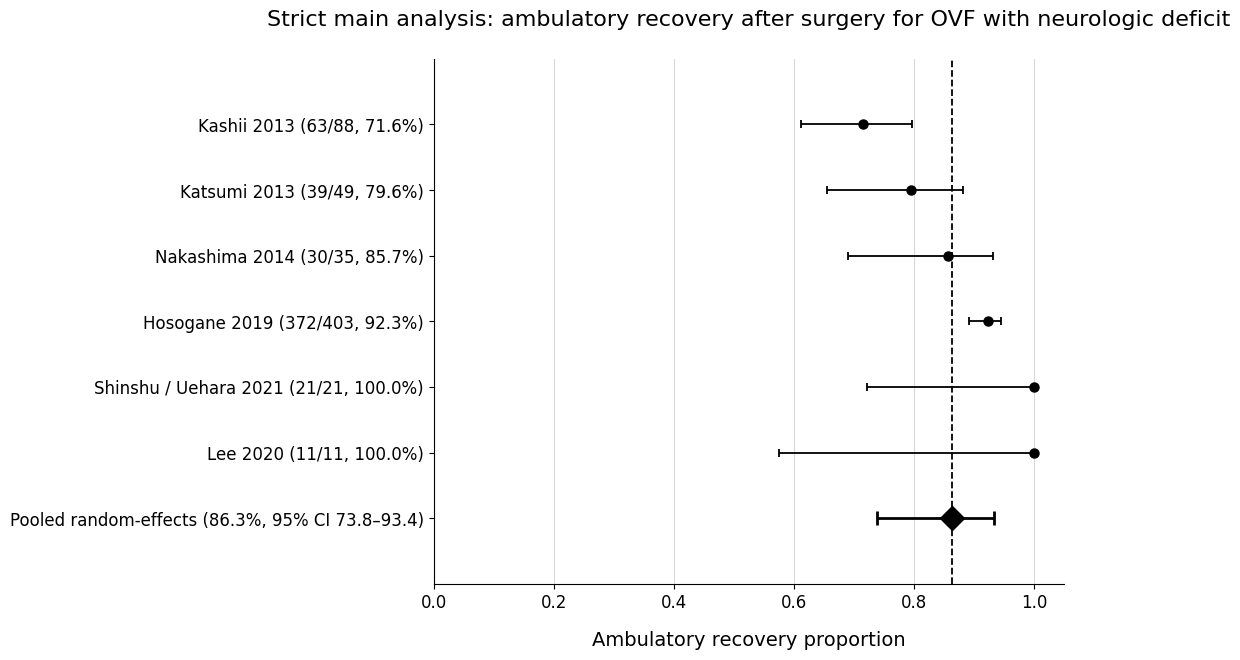

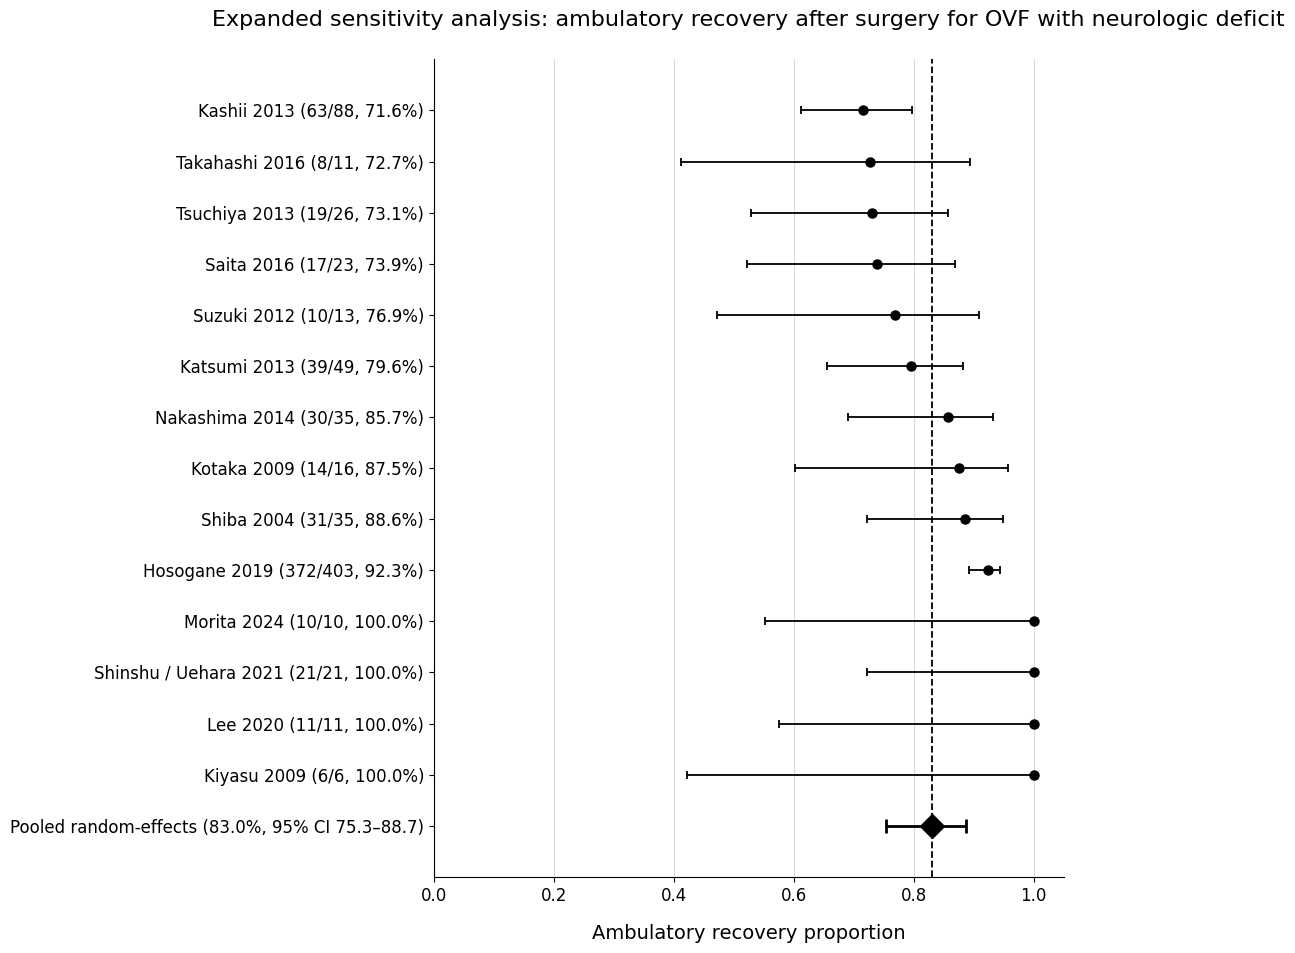


Saved files:
/content/OVF_meta_analysis_results.xlsx
/content/OVF_forest_strict_main.png
/content/OVF_forest_strict_main.pdf
/content/OVF_forest_expanded_sensitivity.png
/content/OVF_forest_expanded_sensitivity.pdf


In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Excel読み込み
# =========================
input_path = "/content/OVF_BJJ_meta_ready.xlsx"
df = pd.read_excel(input_path, sheet_name="analysis_inputs")

df = df.dropna(subset=["Study", "n", "events"])
df["n"] = df["n"].astype(float)
df["events"] = df["events"].astype(float)
df["strict"] = df["Use in strict main?"].eq("YES")
df["expanded"] = df["Use in expanded sensitivity?"].eq("YES")

# =========================
# 2. Random-effects meta-analysis
# =========================
def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def meta_logit_dl(subdf):
    sub = subdf.copy().reset_index(drop=True)

    x = sub["events"].astype(float).values
    n = sub["n"].astype(float).values

    x_cc = x + 0.5
    non_cc = (n - x) + 0.5

    yi = np.log(x_cc / non_cc)
    vi = 1 / x_cc + 1 / non_cc

    wi_fixed = 1 / vi
    y_fixed = np.sum(wi_fixed * yi) / np.sum(wi_fixed)

    Q = np.sum(wi_fixed * (yi - y_fixed) ** 2)
    k = len(yi)
    df_q = k - 1

    C = np.sum(wi_fixed) - (np.sum(wi_fixed ** 2) / np.sum(wi_fixed))
    tau2 = max(0, (Q - df_q) / C) if C > 0 else 0

    wi_random = 1 / (vi + tau2)
    y_pool = np.sum(wi_random * yi) / np.sum(wi_random)
    se_pool = math.sqrt(1 / np.sum(wi_random))

    pooled = float(inv_logit(y_pool))
    ci_low = float(inv_logit(y_pool - 1.96 * se_pool))
    ci_high = float(inv_logit(y_pool + 1.96 * se_pool))

    I2 = max(0, (Q - df_q) / Q) * 100 if Q > 0 else 0

    sub["rate"] = x / n
    sub["ci_low"] = inv_logit(yi - 1.96 * np.sqrt(vi))
    sub["ci_high"] = inv_logit(yi + 1.96 * np.sqrt(vi))

    sub["ci_low_plot"] = np.minimum(sub["ci_low"], sub["rate"])
    sub["ci_high_plot"] = np.maximum(sub["ci_high"], sub["rate"])

    result = {
        "k": k,
        "events_total": int(np.sum(x)),
        "n_total": int(np.sum(n)),
        "crude_rate": float(np.sum(x) / np.sum(n)),
        "pooled_rate": pooled,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "tau2": float(tau2),
        "Q": float(Q),
        "df": int(df_q),
        "I2": float(I2),
    }

    return sub, result

# =========================
# 3. Leave-one-out analysis
# =========================
def leave_one_out(subdf):
    rows = []

    for i, study in enumerate(subdf["Study"]):
        tmp = subdf.drop(subdf.index[i])
        _, res = meta_logit_dl(tmp)

        rows.append({
            "Omitted study": study,
            "k": res["k"],
            "pooled_rate": res["pooled_rate"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
            "I2": res["I2"],
        })

    return pd.DataFrame(rows)

# =========================
# 4. Forest plot
#    Clean BJJ version: no footer
# =========================
def plot_forest(sub, res, title, outpath):

    plot_df = sub.copy().reset_index(drop=True)

    # Higher recovery rate first; older year first if tied
    plot_df["study_year"] = (
        plot_df["Study"]
        .astype(str)
        .str.extract(r"(\d{4})")
        .astype(float)
    )

    plot_df = plot_df.sort_values(
        by=["rate", "study_year"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # Reverse so highest recovery appears at top
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    n_studies = len(plot_df)
    study_y = np.arange(n_studies, 0, -1)
    pooled_y = 0

    rates = plot_df["rate"].values
    low = plot_df["ci_low_plot"].values
    high = plot_df["ci_high_plot"].values

    xerr_low = np.maximum(0, rates - low)
    xerr_high = np.maximum(0, high - rates)

    fig_height = max(7, 0.55 * n_studies + 3.2)

    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    # Individual studies
    ax.errorbar(
        rates,
        study_y,
        xerr=[xerr_low, xerr_high],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=1.3,
        markersize=6.5,
        capsize=3,
        capthick=1.3
    )

    # Pooled reference line
    ax.axvline(
        res["pooled_rate"],
        linestyle="--",
        linewidth=1.3,
        color="black"
    )

    # Pooled diamond
    ax.errorbar(
        res["pooled_rate"],
        pooled_y,
        xerr=[
            [max(0, res["pooled_rate"] - res["ci_low"])],
            [max(0, res["ci_high"] - res["pooled_rate"])]
        ],
        fmt="D",
        color="black",
        ecolor="black",
        elinewidth=2.0,
        markersize=12,
        capsize=5,
        capthick=2.0
    )

    labels = [
        f"{row['Study']} ({int(row['events'])}/{int(row['n'])}, {row['rate']*100:.1f}%)"
        for _, row in plot_df.iterrows()
    ]

    pooled_label = (
        f"Pooled random-effects ({res['pooled_rate']*100:.1f}%, "
        f"95% CI {res['ci_low']*100:.1f}–{res['ci_high']*100:.1f})"
    )

    ax.set_yticks(list(study_y) + [pooled_y])
    ax.set_yticklabels(labels + [pooled_label], fontsize=12)

    ax.set_ylim(-1, n_studies + 1)
    ax.set_xlim(0, 1.05)

    ax.set_xlabel(
        "Ambulatory recovery proportion",
        fontsize=14,
        labelpad=14
    )

    ax.set_title(
        title,
        fontsize=16,
        pad=24
    )

    ax.tick_params(axis="x", labelsize=12)

    ax.grid(
        axis="x",
        color="0.85",
        linewidth=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.38,
        right=0.98,
        top=0.88,
        bottom=0.13
    )

    fig.savefig(outpath, dpi=600, bbox_inches="tight")
    fig.savefig(outpath.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()

# =========================
# 5. Run analyses
# =========================
strict_df, strict_res = meta_logit_dl(df[df["strict"]])
expanded_df, expanded_res = meta_logit_dl(df[df["expanded"]])

strict_loo = leave_one_out(strict_df)
expanded_loo = leave_one_out(expanded_df)

print("Strict main analysis")
print(strict_res)

print("\nExpanded sensitivity analysis")
print(expanded_res)

# =========================
# 6. Forest plots
# =========================
plot_forest(
    strict_df,
    strict_res,
    "Strict main analysis: ambulatory recovery after surgery for OVF with neurologic deficit",
    "/content/OVF_forest_strict_main.png"
)

plot_forest(
    expanded_df,
    expanded_res,
    "Expanded sensitivity analysis: ambulatory recovery after surgery for OVF with neurologic deficit",
    "/content/OVF_forest_expanded_sensitivity.png"
)

# =========================
# 7. Save outputs
# =========================
pooled_results = pd.DataFrame([
    {"Analysis": "Strict main", **strict_res},
    {"Analysis": "Expanded sensitivity", **expanded_res}
])

with pd.ExcelWriter("/content/OVF_meta_analysis_results.xlsx") as writer:
    pooled_results.to_excel(writer, sheet_name="pooled_results", index=False)
    strict_df.to_excel(writer, sheet_name="strict_forest_data", index=False)
    expanded_df.to_excel(writer, sheet_name="expanded_forest_data", index=False)
    strict_loo.to_excel(writer, sheet_name="strict_leave_one_out", index=False)
    expanded_loo.to_excel(writer, sheet_name="expanded_leave_one_out", index=False)

print("\nSaved files:")
print("/content/OVF_meta_analysis_results.xlsx")
print("/content/OVF_forest_strict_main.png")
print("/content/OVF_forest_strict_main.pdf")
print("/content/OVF_forest_expanded_sensitivity.png")
print("/content/OVF_forest_expanded_sensitivity.pdf")